In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.columns = ['X',"Y","class"]
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


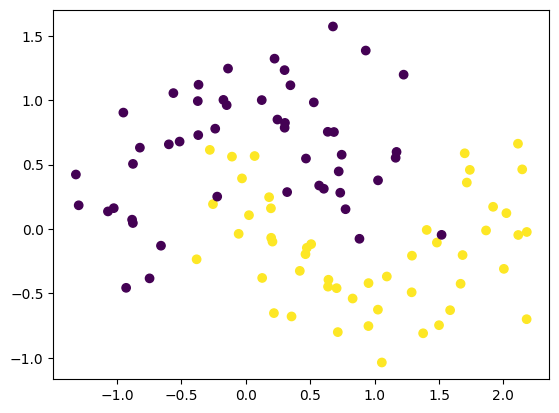

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# For Relu

In [7]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                30        
                                                                 
 dense_1 (Dense)             (None, 1)                 11        
                                                                 
Total params: 41
Trainable params: 41
Non-trainable params: 0
_________________________________________________________________


In [8]:
# Set parameters to 0
model.get_weights()

[array([[-0.49421948, -0.1602683 , -0.6745898 ,  0.5305403 ,  0.01095194,
          0.39103395,  0.593254  ,  0.60089785, -0.6933325 , -0.10699737],
        [-0.26950634, -0.32532662, -0.67929524,  0.38695902, -0.5380084 ,
          0.5041023 , -0.616945  , -0.24366459,  0.1568141 ,  0.1760199 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.29654115],
        [ 0.68800694],
        [ 0.25330025],
        [ 0.5861849 ],
        [ 0.01668727],
        [-0.49797356],
        [-0.12814444],
        [ 0.32374555],
        [ 0.10651237],
        [ 0.13804072]], dtype=float32),
 array([0.], dtype=float32)]

In [9]:
initial_weights = model.get_weights()

In [10]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [11]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [13]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 3s 92ms/step - loss: 0.6932 - accuracy: 0.4557 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 17ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 17ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/100
3/3 [==============================] - 0s 18ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 5/100
3/3 [==============================] - 0s 17ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 17ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 16ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 8/100
3/3 [===

In [14]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.01159297], dtype=float32)]

9600/9600 [==============================] - 13s 1ms/step


<Axes: >

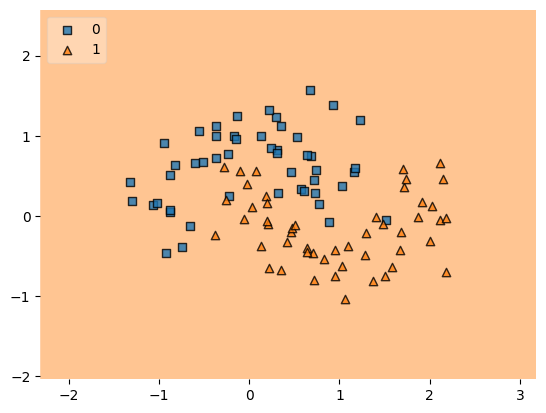

In [15]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

# tanh

In [16]:
model1 = Sequential()

model1.add(Dense(10,activation='tanh',input_dim=2))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 10)                30        
                                                                 
 dense_3 (Dense)             (None, 1)                 11        
                                                                 
Total params: 41
Trainable params: 41
Non-trainable params: 0
_________________________________________________________________


In [17]:
model1.get_weights()

[array([[ 0.16663802,  0.19645941, -0.12639165,  0.23191857,  0.5430277 ,
         -0.2867004 , -0.56723034,  0.3520668 ,  0.11511451,  0.36851293],
        [-0.54677594,  0.62525994,  0.5101003 , -0.46226948, -0.23394331,
         -0.6908701 ,  0.22357774,  0.4552266 , -0.63051754, -0.6029751 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.68577856],
        [ 0.20689684],
        [-0.35122976],
        [-0.5594584 ],
        [-0.66543084],
        [ 0.5264823 ],
        [-0.15961063],
        [-0.12035221],
        [ 0.46889788],
        [ 0.20072001]], dtype=float32),
 array([0.], dtype=float32)]

In [18]:
initial_weights1 = model1.get_weights()

In [19]:
initial_weights1[0] = np.zeros(model1.get_weights()[0].shape)
initial_weights1[1] = np.zeros(model1.get_weights()[1].shape)
initial_weights1[2] = np.zeros(model1.get_weights()[2].shape)
initial_weights1[3] = np.zeros(model1.get_weights()[3].shape)

In [20]:
model1.set_weights(initial_weights1)

In [21]:
model1.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [22]:
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model1.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 0s 73ms/step - loss: 0.6932 - accuracy: 0.3544 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 21ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 20ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/100
3/3 [==============================] - 0s 22ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 5/100
3/3 [==============================] - 0s 19ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 20ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 19ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 8/100
3/3 [===

In [23]:
model1.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.00904674], dtype=float32)]

9600/9600 [==============================] - 14s 1ms/step


<Axes: >

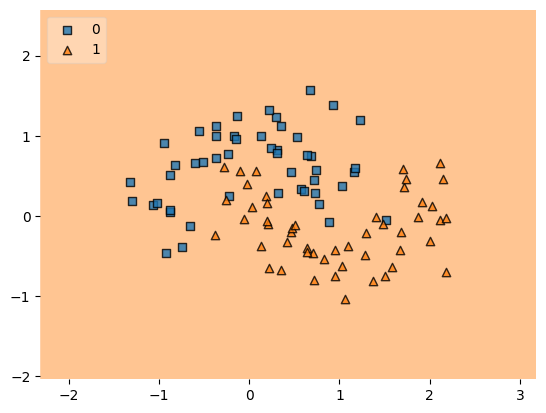

In [24]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model1, legend=2)

# Sigmoid

In [34]:
model2 = Sequential()

model2.add(Dense(10,activation='sigmoid',input_dim=2))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                30        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 41
Trainable params: 41
Non-trainable params: 0
_________________________________________________________________


In [35]:
model2.get_weights()

[array([[ 0.38600272, -0.56295276, -0.6540749 ,  0.23243481,  0.580234  ,
          0.37058395,  0.36019236,  0.15649498,  0.03929013, -0.06121051],
        [ 0.12666142,  0.4924726 , -0.3735681 ,  0.6045328 , -0.41005394,
         -0.5517742 ,  0.548431  ,  0.48473185,  0.43014902,  0.2980327 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-2.9247999e-04],
        [-5.1327336e-01],
        [-5.8075076e-01],
        [ 5.4428667e-01],
        [ 6.5909427e-01],
        [-7.1347916e-01],
        [ 6.5049642e-01],
        [ 2.2717047e-01],
        [ 4.9394518e-01],
        [-1.6300410e-01]], dtype=float32),
 array([0.], dtype=float32)]

In [36]:
new_Weights = model2.get_weights()

In [37]:
new_Weights[0] = np.zeros(model2.get_weights()[0].shape)
new_Weights[1] = np.zeros(model2.get_weights()[1].shape)
new_Weights[2] = np.zeros(model2.get_weights()[2].shape)
new_Weights[3] = np.zeros(model2.get_weights()[3].shape)

In [38]:
model2.set_weights(new_Weights)

In [39]:
model2.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [40]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model2.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 0s 71ms/step - loss: 0.6935 - accuracy: 0.4937 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 23ms/step - loss: 0.6932 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 24ms/step - loss: 0.6932 - accuracy: 0.4810 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 4/100
3/3 [==============================] - 0s 25ms/step - loss: 0.6932 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 5/100
3/3 [==============================] - 0s 22ms/step - loss: 0.6932 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 21ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 24ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 8/100
3/3 [===

In [41]:
model2.get_weights()

[array([[ 0.42274463,  0.42274463,  0.42274463,  0.42274463,  0.42274463,
          0.42274463,  0.42274463,  0.42274463,  0.42274463,  0.42274463],
        [-0.46367547, -0.46367547, -0.46367547, -0.46367547, -0.46367547,
         -0.46367547, -0.46367547, -0.46367547, -0.46367547, -0.46367547]],
       dtype=float32),
 array([-0.1379119 , -0.1379119 , -0.13791192, -0.13791192, -0.1379119 ,
        -0.1379119 , -0.13791192, -0.13791192, -0.1379119 , -0.1379119 ],
       dtype=float32),
 array([[0.05835405],
        [0.05835405],
        [0.05835405],
        [0.05835405],
        [0.05835405],
        [0.05835405],
        [0.05835405],
        [0.05835405],
        [0.05835405],
        [0.05835405]], dtype=float32),
 array([-0.06356357], dtype=float32)]

9600/9600 [==============================] - 13s 1ms/step


<Axes: >

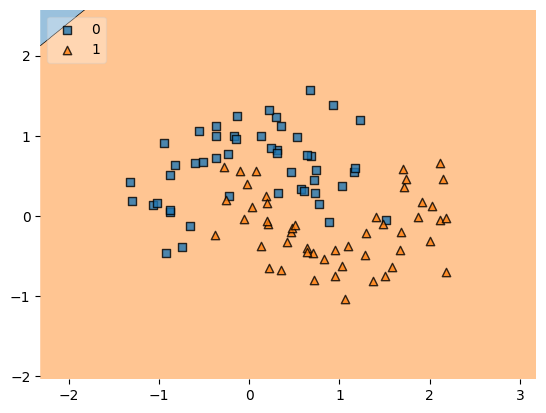

In [42]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model2, legend=2)